In [1]:
import torch
import torch.nn as nn
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, TensorDataset

%matplotlib inline
from matplotlib_inline import backend_inline
import matplotlib.pyplot as plt
backend_inline.set_matplotlib_formats('svg')


In [2]:
# ========== 0. 全局配置与设备检查 ==========
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"当前使用的计算设备: {device}")


当前使用的计算设备: cuda


In [3]:
#载入数据集
train_dataset = datasets.CIFAR10(root='C:/Jupyter(Anaconda)/data', train=True, download=False)
test_dataset = datasets.CIFAR10(root='C:/Jupyter(Anaconda)/data', train=False, download=False)

In [4]:
# ========== 数据增强：在 CPU 上对 numpy 数组批量操作 ==========
# 增强操作：水平翻转 + 随机裁剪（每张原图生成 N_AUG 份增强图）
N_AUG = 1   # 每张原图增强次数，最终训练集 = 原图 × (1 + N_AUG)

aug_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.5), # 随机水平翻转
    transforms.RandomCrop(32, padding=2),   # 随机裁剪
    transforms.ColorJitter(brightness=0.1,  # 颜色抖动
                           contrast=0.1,
                           saturation=0.1),
    transforms.ToTensor(),                  # 输出 [0,1] float tensor (C,H,W)
])

def apply_augmentation(imgs_np, n_aug=1):#先扩增数据集，之后一起训练
    """
    imgs_np: (N, 32, 32, 3) uint8 numpy
    返回: (N*(1+n_aug), 3, 32, 32) float32 CPU Tensor，值域 [0,1]
    原图（转 tensor）在前，增强图在后
    """
    N = len(imgs_np)
    # 原图直接转 tensor：(N, 3, 32, 32)，归一化到 [0,1]
    originals = torch.from_numpy(imgs_np).permute(0, 3, 1, 2).float().div_(255.0)

    aug_list = [originals]
    for _ in range(n_aug):
        aug_batch = torch.stack([aug_transform(imgs_np[i]) for i in range(N)])
        aug_list.append(aug_batch)             # 每次生成 (N, 3, 32, 32)

    return torch.cat(aug_list, dim=0)          # (N*(1+n_aug), 3, 32, 32)

print("正在进行数据增强...")
X_train = apply_augmentation(train_dataset.data, n_aug=N_AUG)   # (N*(1+N_AUG), 3, 32, 32)
y_train = torch.tensor(
    train_dataset.targets * (1 + N_AUG)          # 标签同步扩充：[原图标签, 增强1标签, ...]
)
X_test = torch.from_numpy(test_dataset.data).permute(0, 3, 1, 2).float().div_(255.0)
y_test = torch.tensor(test_dataset.targets)
print(f"增强后训练集大小: {X_train.shape[0]} 张")

正在进行数据增强...
增强后训练集大小: 100000 张


In [5]:
train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=250,
    shuffle=True,
    drop_last=True,                 # 丢弃最后不足 batch_size 的样本
    pin_memory=(device.type == "cuda")
)

test_loader = DataLoader(
    TensorDataset(X_test, y_test),
    batch_size=500,
    shuffle=False,
    pin_memory=(device.type == "cuda")
)

In [6]:
class TrainModel(nn.Module):
    def __init__(self):
        super(TrainModel,self).__init__()
        self.net=nn.Sequential(
            nn.Flatten(),
            nn.Linear(3072,1024),
            nn.BatchNorm1d(1024),
            nn.GELU(),
            nn.Dropout(p=0.3),
            nn.Linear(1024,512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(p=0.2),
            nn.Linear(512,256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Linear(256,64),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.Linear(64,10)
        )
    def forward(self,X):
        y=self.net(X)
        return y

TrainModel=TrainModel().to(device)
loss_fn1=nn.CrossEntropyLoss()
%run MulClassSVM.ipynb
loss_fn2=MultiClassSVM()

In [13]:
learning_rate=0.000002
optimizer=torch.optim.Adam(
    TrainModel.parameters(),
    lr=learning_rate,
    weight_decay=0.001
)
# 余弦退火调度器：随 epoch 平滑降低学习率
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=16)

Epoch [01/15]  Train Acc: 73.4720%  lr: 1.98e-06
Epoch [02/15]  Train Acc: 73.6670%  lr: 1.92e-06
Epoch [03/15]  Train Acc: 73.7900%  lr: 1.83e-06
Epoch [04/15]  Train Acc: 73.8070%  lr: 1.71e-06
Epoch [05/15]  Train Acc: 73.5990%  lr: 1.56e-06
Epoch [06/15]  Train Acc: 73.7390%  lr: 1.38e-06
Epoch [07/15]  Train Acc: 73.8980%  lr: 1.20e-06
Epoch [08/15]  Train Acc: 73.7450%  lr: 1.00e-06
Epoch [09/15]  Train Acc: 74.1040%  lr: 8.05e-07
Epoch [10/15]  Train Acc: 73.8220%  lr: 6.17e-07
Epoch [11/15]  Train Acc: 73.9620%  lr: 4.44e-07
Epoch [12/15]  Train Acc: 73.9790%  lr: 2.93e-07
Epoch [13/15]  Train Acc: 73.9400%  lr: 1.69e-07
Epoch [14/15]  Train Acc: 74.0430%  lr: 7.61e-08
Epoch [15/15]  Train Acc: 73.9610%  lr: 1.92e-08


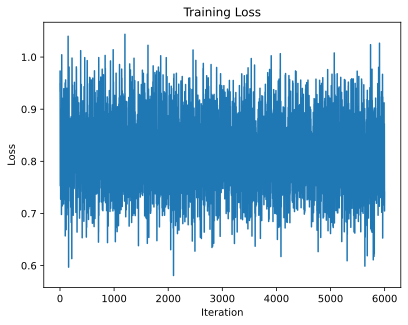

In [14]:
#训练网络
epochs=15
losses=[]
for epoch in range(epochs):
    TrainModel.train() #训练模式
    correct=0
    total=0
    for (x,y) in train_loader:#获取小批次x,y
        x,y=x.to(device),y.to(device)

        Pred=TrainModel(x)#一次前向传播
        loss=0.85*loss_fn1(Pred,y)+0.15*loss_fn2(Pred,y)#计算损失函数
        losses.append(loss.item())
        optimizer.zero_grad()#清理上一轮滞留的梯度
        loss.backward()#一次反向传播
        optimizer.step()#优化内部参数

        correct    += (Pred.argmax(dim=1) == y).sum().item()
        total      += y.size(0)
    scheduler.step()
    train_acc  = correct    / total
    #test_acc   = evaluate(test_loader)

    # 保存最优模型
    #if test_acc > best_acc:
        #best_acc = test_acc
        #torch.save(model.state_dict(), "best_mlp.pth")

    print(f"Epoch [{epoch+1:02d}/{epochs}]  "
          f"Train Acc: {100*train_acc:.4f}%  "
          f"lr: {scheduler.get_last_lr()[0]:.2e}")

# 绘制损失曲线
Fig = plt.figure()
plt.plot(range(len(losses)), losses)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

In [15]:
def evaluate(loader):
    """返回在给定 loader 上的准确率"""
    TrainModel.eval()
    correct = total = 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = TrainModel(X_batch).argmax(dim=1)
            correct += (preds == y_batch).sum().item()
            total   += y_batch.size(0)
    return correct / total

print("正在评估测试集...")#62.25% 20epochs
print(f"测试集准确率：{evaluate(test_loader)*100:.4f}%")

正在评估测试集...
测试集准确率：62.4900%


In [ ]:
#torch.save(TrainModel.state_dict(), "62d25_mlp.pth")

In [11]:
#BestModel=TrainModel()
#BestModel.load_state_dict(torch.load("best_mlp.pth"))